In [24]:
import re
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.visualization_utils import save_figure_pdf

In [25]:
# Exactly ONE of the three variables should be None at a time; the other two
# must be set to a single valid string from the canonical orders below.
FIXED_METHODS:  str | None = "anndgE"      # set to None to vary methods
FIXED_SAMPLERS: str | None = None          # set to None to vary samplers
FIXED_FEATURES: str | None = "log_bin_deg" # set to None to vary features (currently unused: features always log_bin_deg)

DATA_DIR          = PROJECT_ROOT / "data"
SYNTHETIC_DATA_DIR = PROJECT_ROOT / "synthetic_data"
DATASET_NAMES = [
    "BZR", "DHFR", "MUTAG", "Mutagenicity", "AIDS", "COX2", "NCI1", "NCI109", "PTC_FM", "PTC_FR", "PTC_MM", "PTC_MR", "PROTEINS", "ENZYMES", "Cuneiform", "MSRC_9", "MSRC_21", "MSRC_21C"
]

# Methods
METHOD_ORDER = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "ergm", "nextGen"]
METHOD_PALETTE = {
    "original":   "#5B9BD5",
    "dummyNodes": "#E07A5F",
    "dummyEdges": "#F4A261",
    "padma":      "#F2CC8F",
    "anndg":      "#8A4F7D",
    "anndgE":     "#B56576",
    "ergm":       "#6B705C",
    "nextGen":    "#9E2A2B",
}

# Samplers (None is stored as "nosampler" in filenames)
SAMPLER_ORDER = ["nosampler", "moments", "percentile", "percentile_corr", "gmcm"]
SAMPLER_PALETTE = {
    "nosampler":       "#5B9BD5",
    "moments":         "#B5C99A",
    "percentile":      "#71A070",
    "percentile_corr": "#2C6E49",
    "gmcm":            "#D2A85C",
}

METHOD_LABELS: dict[str, str] = {
    "original":              "Original",
    "dummyNodes":            "DummyNodes",
    "dummyEdges":            "DummyEdges",
    "padma":                 "PADMA",
    "anndg":                 "DpfAnnd",
    "anndgD":                "DpfAnnd+D",
    "anndgE":                "DpfAnnd+E",
    "anndgED":               "DpfAnnd+ED",
    "ergm":                  "GARME",
    "nextGen":               "NextGen",
    "nosampler":             "No Sampler",
    "moments":               "Moments",
    "percentile":            "Percentile",
    "percentile_corr":       "Percentile Corr",
    "gmcm":                  "GMCM",
    "constant":              "Constant",
    "log_bin_deg":           "Log Bin Deg",
    "random_sample":         "Random Sample",
    "degree_ordered":        "Degree Ordered",
    "neighbor_degree_ordered": "Neighbor Deg Ord",
}

# Per-graph statistics keys stored in metadata (in order of flatten_stats)
STAT_KEYS = ["n_nodes", "n_edges", "degree_moments", "annd", "eccentricity"]

# Human-readable labels for statistics (scalar or per-component if vector)
STAT_LABELS = {
    "n_nodes":          ["n_nodes"],
    "n_edges":          ["n_edges"],
    "degree_moments":   ["deg_mean", "deg_var", "deg_skew", "deg_kurt"],
    "annd":             ["annd_0", "annd_1", "annd_2", "annd_3"],
    "eccentricity":     ["ecc_0", "ecc_1", "ecc_2", "ecc_3"],
}

def _canonical_order(values, order):
    """Return values sorted by canonical order, with unknown values appended."""
    present = set(values)
    return [v for v in order if v in present] + sorted(v for v in present if v not in order)


def _stat_to_flat_dict(stat: dict) -> dict:
    """Flattens a per-graph statistics dict into a flat dict of scalar values.

    Vector statistics (degree_moments, annd, eccentricity) are expanded into
    individual named columns following STAT_LABELS.

    Args:
        stat: A per-graph statistics dict as stored in .pt metadata.
    Returns:
        A flat dict mapping column name -> scalar float (or NaN if missing).
    """
    row = {}
    for key, labels in STAT_LABELS.items():
        val = stat.get(key)
        if len(labels) == 1:
            # Scalar statistic
            row[labels[0]] = float(val) if val is not None else float("nan")
        else:
            # Vector statistic
            arr = np.array(val, dtype=float) if val is not None else np.full(len(labels), float("nan"))
            for i, lbl in enumerate(labels):
                row[lbl] = float(arr[i]) if i < len(arr) else float("nan")
    return row

# All flat column names (in order)
ALL_STAT_COLS: list[str] = [lbl for labels in STAT_LABELS.values() for lbl in labels]

def load_original_stats() -> pd.DataFrame:
    """Loads per-graph statistics from every original dataset .pt file.

    Tries the naming conventions used by the pipeline in order:
      1. ``{DATASET}_original_{FIXED_FEATURES}.pt``  (new naming with feature suffix)
      2. ``{DATASET}_original_native.pt``             (per-graph feature variant)
      3. ``{DATASET}_original.pt``                    (legacy naming, no suffix)

    Returns:
        A single DataFrame with columns 'dataset', 'graph_idx', and one column
        per entry in ALL_STAT_COLS.  Datasets for which no .pt file is found
        are omitted with a warning.
    """
    candidate_suffixes = [
        f"_original_{FIXED_FEATURES}.pt" if FIXED_FEATURES else "_original_log_bin_deg.pt",
        "_original_native.pt",
        "_original.pt",
    ]

    all_dfs: list[pd.DataFrame] = []
    for dname in DATASET_NAMES:
        loaded = False
        for suffix in candidate_suffixes:
            pt_path = DATA_DIR / dname / f"{dname}{suffix}"
            if not pt_path.exists():
                continue
            try:
                payload = torch.load(pt_path, map_location="cpu", weights_only=False)
                per_graph_stats = payload.get("metadata", {}).get("per_graph_statistics", [])
                if not per_graph_stats:
                    continue
                rows = []
                for i, stat in enumerate(per_graph_stats):
                    if stat is None:
                        continue
                    row = _stat_to_flat_dict(stat)
                    row["graph_idx"] = i
                    rows.append(row)
                if rows:
                    df_ds = pd.DataFrame(rows)
                    df_ds.insert(0, "dataset", dname)
                    all_dfs.append(df_ds)
                    print(f"[original] {dname}: {len(rows)} graphs loaded from '{pt_path.name}'.")
                    loaded = True
                    break
            except Exception as e:
                print(f"Warning: Failed to load {pt_path.name}: {e}")
        if not loaded:
            print(f"Warning: No original .pt found for dataset '{dname}' (tried: {candidate_suffixes}).")

    if not all_dfs:
        raise FileNotFoundError(f"No original dataset .pt files found for any of: {DATASET_NAMES}.")

    return pd.concat(all_dfs, ignore_index=True)

def load_synthetic_stats() -> pd.DataFrame:
    """Loads per-graph target and synthetic statistics from all matching .pt files.

    Scans ``SYNTHETIC_DATA_DIR`` for files matching::

        {dataset}_{method}_{sampler}_{feature}_v{variant}.pt

    applying the active FIXED_* filters. For each matched file it reads both
    ``per_graph_target_statistics`` and ``per_graph_statistics`` from the
    embedded metadata and returns a flat DataFrame where each row corresponds
    to one graph in one variant, with both target and synthetic stat columns.

    Returns:
        A DataFrame with columns:
            dataset, method, sampler, feature, variant, graph_idx,
            target_{col} and synth_{col} for each col in ALL_STAT_COLS.
        Raises FileNotFoundError if no .pt files are found in SYNTHETIC_DATA_DIR.
        Raises ValueError if no rows match the active FIXED_* filters.
    """
    dataset_alts = "|".join(re.escape(d) for d in sorted(DATASET_NAMES, key=len, reverse=True))
    sampler_alts = "|".join(re.escape(s) for s in sorted(SAMPLER_ORDER, key=len, reverse=True))
    filename_pattern = re.compile(
        r"(?P<dataset>" + dataset_alts + r")_"            # dataset name
        r"(?P<method>[A-Za-z][A-Za-z0-9]*)_"             # method name
        r"(?P<sampler>" + sampler_alts + r")_"            # sampler (exact match, longest first)
        r"(?P<feature>[a-zA-Z0-9_]+)_"                    # feature strategy
        r"v(?P<variant>\d+)\.pt$"                         # variant index
    )

    pt_paths = list(SYNTHETIC_DATA_DIR.glob("*.pt"))
    if not pt_paths:
        raise FileNotFoundError(f"No synthetic .pt files found in {SYNTHETIC_DATA_DIR}.")

    print(f"Scanning {len(pt_paths)} files in {SYNTHETIC_DATA_DIR}...")

    rows = []
    for pt_path in pt_paths:
        match = filename_pattern.match(pt_path.name)
        if match is None:
            continue

        dataset = match.group("dataset")
        method  = match.group("method")
        sampler = match.group("sampler")
        feature = match.group("feature")
        variant = int(match.group("variant"))

        if dataset not in DATASET_NAMES:
            continue
        if FIXED_METHODS  is not None and method  != FIXED_METHODS:
            continue
        if FIXED_SAMPLERS is not None and sampler != FIXED_SAMPLERS:
            continue
        if FIXED_FEATURES is not None and feature != FIXED_FEATURES:
            continue

        try:
            payload  = torch.load(pt_path, map_location="cpu", weights_only=False)
            metadata = payload.get("metadata", {})
        except Exception as e:
            print(f"Warning: Failed to load {pt_path.name}: {e}")
            continue

        target_stats = metadata.get("per_graph_target_statistics", [])
        synth_stats  = metadata.get("per_graph_statistics", [])

        if not target_stats or not synth_stats:
            continue

        n_graphs = min(len(target_stats), len(synth_stats))
        for i in range(n_graphs):
            t_stat = target_stats[i]
            s_stat = synth_stats[i]
            if t_stat is None or s_stat is None:
                continue

            row: dict = {
                "dataset": dataset,
                "method":  method,
                "sampler": sampler,
                "feature": feature,
                "variant": variant,
                "graph_idx": i,
            }
            # Target statistics (what the generator was asked to produce)
            for col, val in _stat_to_flat_dict(t_stat).items():
                row[f"target_{col}"] = val
            # Synthetic statistics (what was actually generated)
            for col, val in _stat_to_flat_dict(s_stat).items():
                row[f"synth_{col}"] = val

            rows.append(row)

    if not rows:
        raise ValueError(
            f"No matching synthetic data found. "
            f"Check FIXED_METHODS={FIXED_METHODS}, FIXED_SAMPLERS={FIXED_SAMPLERS}, "
            f"FIXED_FEATURES={FIXED_FEATURES}."
        )

    df = pd.DataFrame(rows)

    # Apply canonical categorical orderings
    all_methods  = set(df["method"].unique())
    all_samplers = set(df["sampler"].unique())
    df["method"]  = pd.Categorical(df["method"],  categories=_canonical_order(all_methods,  METHOD_ORDER),  ordered=True)
    df["sampler"] = pd.Categorical(df["sampler"], categories=_canonical_order(all_samplers, SAMPLER_ORDER), ordered=True)

    print(
        f"Successfully loaded {len(df)} records "
        f"({df['dataset'].nunique()} datasets, "
        f"{df['method'].nunique()} methods, "
        f"{df['sampler'].nunique()} samplers, "
        f"{df['variant'].nunique()} variants)."
    )
    return df

df_original: pd.DataFrame  = load_original_stats()
df_synthetic: pd.DataFrame = load_synthetic_stats()
DATASETS  = [d for d in DATASET_NAMES if d in df_synthetic["dataset"].unique()]
METHODS   = _canonical_order(set(df_synthetic["method"].dropna().unique()), METHOD_ORDER)
SAMPLERS  = _canonical_order(set(df_synthetic["sampler"].dropna().unique()), SAMPLER_ORDER)

[original] BZR: 405 graphs loaded from 'BZR_original_log_bin_deg.pt'.
[original] DHFR: 500 graphs loaded from 'DHFR_original_log_bin_deg.pt'.
[original] MUTAG: 188 graphs loaded from 'MUTAG_original_log_bin_deg.pt'.
[original] Mutagenicity: 500 graphs loaded from 'Mutagenicity_original_log_bin_deg.pt'.
[original] AIDS: 500 graphs loaded from 'AIDS_original_log_bin_deg.pt'.
[original] COX2: 467 graphs loaded from 'COX2_original_log_bin_deg.pt'.
[original] NCI1: 500 graphs loaded from 'NCI1_original_log_bin_deg.pt'.
[original] NCI109: 500 graphs loaded from 'NCI109_original_log_bin_deg.pt'.
[original] PTC_FM: 349 graphs loaded from 'PTC_FM_original_log_bin_deg.pt'.
[original] PTC_FR: 351 graphs loaded from 'PTC_FR_original_log_bin_deg.pt'.
[original] PTC_MM: 336 graphs loaded from 'PTC_MM_original_log_bin_deg.pt'.
[original] PTC_MR: 344 graphs loaded from 'PTC_MR_original_log_bin_deg.pt'.
[original] PROTEINS: 500 graphs loaded from 'PROTEINS_original_log_bin_deg.pt'.
[original] ENZYMES: 

[save_figure_pdf] Saved → /home/amarigo/syn_bench_gnn2/syn_bench_gnn/dataset_distribution_modelling.pdf


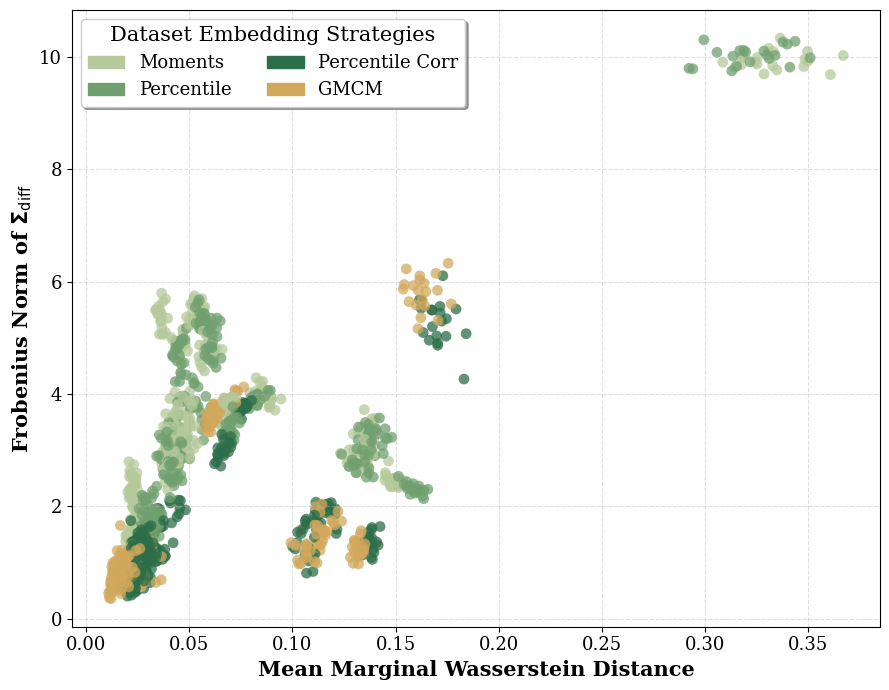

In [26]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

def _resolve_vary_col() -> tuple[str, list, dict, str]:
    """Returns (col_name, ordered_values, palette, axis_label) for the free axis."""
    if FIXED_METHODS is None:
        return "method", METHODS, METHOD_PALETTE, "Generator Method"
    if FIXED_SAMPLERS is None:
        return "sampler", SAMPLERS, SAMPLER_PALETTE, "Dataset Embedding Strategies"
    raise ValueError("Exactly one of FIXED_METHODS or FIXED_SAMPLERS must be None.")

def _compute_marginal_errors(dataset: str, vary_col: str, vary_vals: list) -> pd.DataFrame:
    """Computes the mean Wasserstein distance (MinMax-scaled on Original) per (vary_val, variant).
    Scaling is fitted exclusively on the Original data, then applied to Target and Synthetic.

    Args:
        dataset: Dataset name to restrict computation to.
        vary_col: Column name of the free axis ('method' or 'sampler').
        vary_vals: Ordered list of values along the free axis.
    Returns:
        DataFrame with columns [vary_col, 'variant', 'marginal_error_target', 'marginal_error_synth'].
    """
    orig = df_original[df_original["dataset"] == dataset][ALL_STAT_COLS].dropna()
    synth_ds = df_synthetic[df_synthetic["dataset"] == dataset]

    # Fit scaler on Original only
    scaler = MinMaxScaler()
    scaler.fit(orig)
    orig_scaled = scaler.transform(orig)

    rows = []
    for val in vary_vals:
        sub = synth_ds[synth_ds[vary_col] == val]
        for variant, grp in sub.groupby("variant", observed=True):
            target_scaled = scaler.transform(
                grp[[f"target_{c}" for c in ALL_STAT_COLS]]
                .rename(columns={f"target_{c}": c for c in ALL_STAT_COLS})
                .fillna(0)
            )
            synth_scaled = scaler.transform(
                grp[[f"synth_{c}" for c in ALL_STAT_COLS]]
                .rename(columns={f"synth_{c}": c for c in ALL_STAT_COLS})
                .fillna(0)
            )

            w_target = np.mean([
                wasserstein_distance(orig_scaled[:, j], target_scaled[:, j])
                for j in range(len(ALL_STAT_COLS))
            ])
            w_synth = np.mean([
                wasserstein_distance(orig_scaled[:, j], synth_scaled[:, j])
                for j in range(len(ALL_STAT_COLS))
            ])
            rows.append({vary_col: val, "variant": variant, "marginal_error_target": w_target, "marginal_error_synth": w_synth})

    return pd.DataFrame(rows)

def _compute_joint_errors(dataset: str, vary_col: str, vary_vals: list) -> pd.DataFrame:
    """Computes the Frobenius norm ||C_orig - C_generated|| (joint / correlation error).
    Correlation is scale-invariant, so raw (unscaled) values are used directly.

    Args:
        dataset: Dataset name.
        vary_col: Column name of the free axis.
        vary_vals: Ordered list of values along the free axis.
    Returns:
        DataFrame with columns [vary_col, 'variant', 'joint_error_target', 'joint_error_synth'].
    """
    orig = df_original[df_original["dataset"] == dataset][ALL_STAT_COLS].dropna()
    c_orig = np.nan_to_num(orig.corr(method="spearman").to_numpy(), nan=0.0)

    synth_ds = df_synthetic[df_synthetic["dataset"] == dataset]

    rows = []
    for val in vary_vals:
        sub = synth_ds[synth_ds[vary_col] == val]
        for variant, grp in sub.groupby("variant", observed=True):
            target_df = (
                grp[[f"target_{c}" for c in ALL_STAT_COLS]]
                .rename(columns={f"target_{c}": c for c in ALL_STAT_COLS})
                .dropna()
            )
            c_target = np.nan_to_num(target_df.corr(method="spearman").to_numpy(), nan=0.0)
            frob_target = np.linalg.norm(c_orig - c_target, ord="fro")

            synth_df = (
                grp[[f"synth_{c}" for c in ALL_STAT_COLS]]
                .rename(columns={f"synth_{c}": c for c in ALL_STAT_COLS})
                .dropna()
            )
            c_synth = np.nan_to_num(synth_df.corr(method="spearman").to_numpy(), nan=0.0)
            frob_synth = np.linalg.norm(c_orig - c_synth, ord="fro")

            rows.append({vary_col: val, "variant": variant, "joint_error_target": frob_target, "joint_error_synth": frob_synth})

    return pd.DataFrame(rows)

def plot_marginal_vs_joint(error_col: str = "synth") -> None:
    """Scatter: mean Wasserstein (x) vs Frobenius norm of delta-Correlation (y).

    Each point is one (vary_val, variant) pair.
    All datasets use uniform circle markers; vary_val encoded as colour.

    Args:
        error_col: 'target' or 'synth' — which comparison to plot.
    """
    vary_col, vary_vals, palette, axis_label = _resolve_vary_col()

    fig, ax = plt.subplots(figsize=(9, 7))
    suffix = "Target\u2192Original" if error_col == "target" else "Synthetic\u2192Original"

    for dataset in DATASETS:
        df_marg  = _compute_marginal_errors(dataset, vary_col, vary_vals)
        df_joint = _compute_joint_errors(dataset, vary_col, vary_vals)
        merged   = df_marg.merge(df_joint, on=[vary_col, "variant"])

        for val in vary_vals:
            sub = merged[merged[vary_col] == val]
            if sub.empty:
                continue
            ax.scatter(
                sub[f"marginal_error_{error_col}"],
                sub[f"joint_error_{error_col}"],
                color=palette.get(val, "#AAAAAA"),
                marker="o",
                s=60, alpha=0.75, edgecolors="none",
            )

    legend_patches = [
        mpatches.Patch(color=palette.get(v, "#AAAAAA"), label=METHOD_LABELS.get(str(v), str(v).replace("_", " ")))
        for v in vary_vals
    ]
    ax.legend(handles=legend_patches, title=axis_label, fontsize=13, title_fontsize=15, frameon=True, shadow=True, ncol=2)
    ax.set_xlabel("Mean Marginal Wasserstein Distance", fontsize=15, fontweight="bold")
    ax.set_ylabel(r"Frobenius Norm of $\mathbf{\Sigma_\text{diff}}$", fontsize=15, fontweight="bold")
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_figure_pdf(fig, ax, PROJECT_ROOT / "dataset_distribution_modelling.pdf")
    plt.show()

plot_marginal_vs_joint(error_col="synth")

[save_figure_pdf] Saved → /home/amarigo/syn_bench_gnn2/syn_bench_gnn/complete_dataset_distribution_modelling.pdf


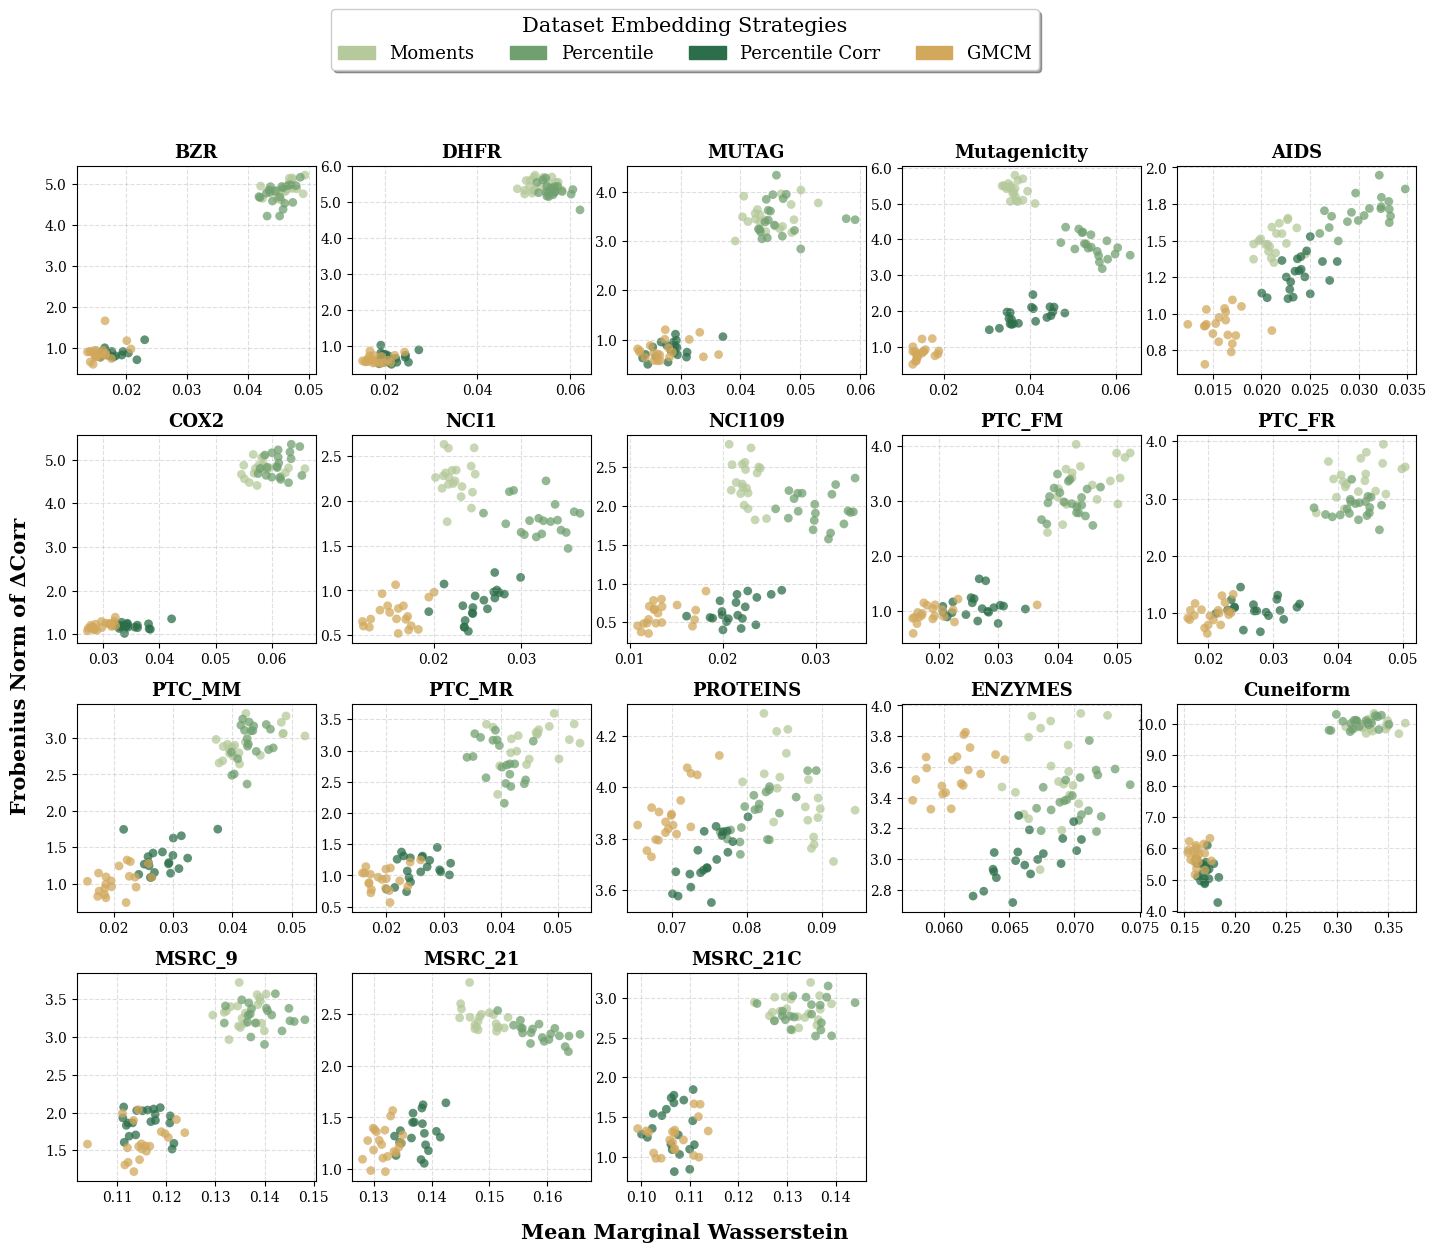

In [27]:
def plot_marginal_vs_joint_per_dataset(error_col: str = "synth") -> None:
    """Scatter: mean Wasserstein (x) vs Frobenius norm of delta-Correlation (y) per dataset.

    Creates a macro figure with 3 subplots per row, one for each dataset.
    """
    vary_col, vary_vals, palette, axis_label = _resolve_vary_col()

    n_datasets = len(DATASETS)
    if n_datasets == 0:
        print("No datasets to plot.")
        return

    n_cols = 5
    n_rows = (n_datasets + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows + 0.8), squeeze=False)
    suffix = "Target\u2192Original" if error_col == "target" else "Synthetic\u2192Original"

    for i, dataset in enumerate(DATASETS):
        r, c = divmod(i, n_cols)
        ax = axes[r, c]

        df_marg  = _compute_marginal_errors(dataset, vary_col, vary_vals)
        df_joint = _compute_joint_errors(dataset, vary_col, vary_vals)
        merged   = df_marg.merge(df_joint, on=[vary_col, "variant"])

        for val in vary_vals:
            sub = merged[merged[vary_col] == val]
            if sub.empty:
                continue
            ax.scatter(
                sub[f"marginal_error_{error_col}"],
                sub[f"joint_error_{error_col}"],
                color=palette.get(val, "#AAAAAA"),
                marker="o",
                s=40, alpha=0.75, edgecolors="none",
            )

        ax.set_title(dataset, fontsize=13, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Hide any empty subplots
    for i in range(n_datasets, n_rows * n_cols):
        r, c = divmod(i, n_cols)
        axes[r, c].set_visible(False)

    legend_patches = [
        mpatches.Patch(color=palette.get(v, "#AAAAAA"), label=METHOD_LABELS.get(str(v), str(v).replace("_", " ")))
        for v in vary_vals
    ]
    fig.legend(
        handles=legend_patches,
        title=axis_label,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        fontsize=13,
        title_fontsize=15,
        frameon=True,
        shadow=True,
        ncol=min(len(vary_vals), 5),
    )

    fig.supxlabel("Mean Marginal Wasserstein", fontsize=15, fontweight="bold", y=0.05)
    fig.supylabel("Frobenius Norm of \u0394Corr", fontsize=15, fontweight="bold", x=0.05)

    fig.tight_layout(rect=[0.04, 0.04, 1.0, 0.92])
    fig.subplots_adjust(wspace=0.15)
    save_figure_pdf(fig, ax, PROJECT_ROOT / "complete_dataset_distribution_modelling.pdf")
    plt.show()

plot_marginal_vs_joint_per_dataset(error_col="synth")

[save_figure_pdf] Saved → /home/amarigo/syn_bench_gnn2/syn_bench_gnn/dataset_distribution_modelling.pdf


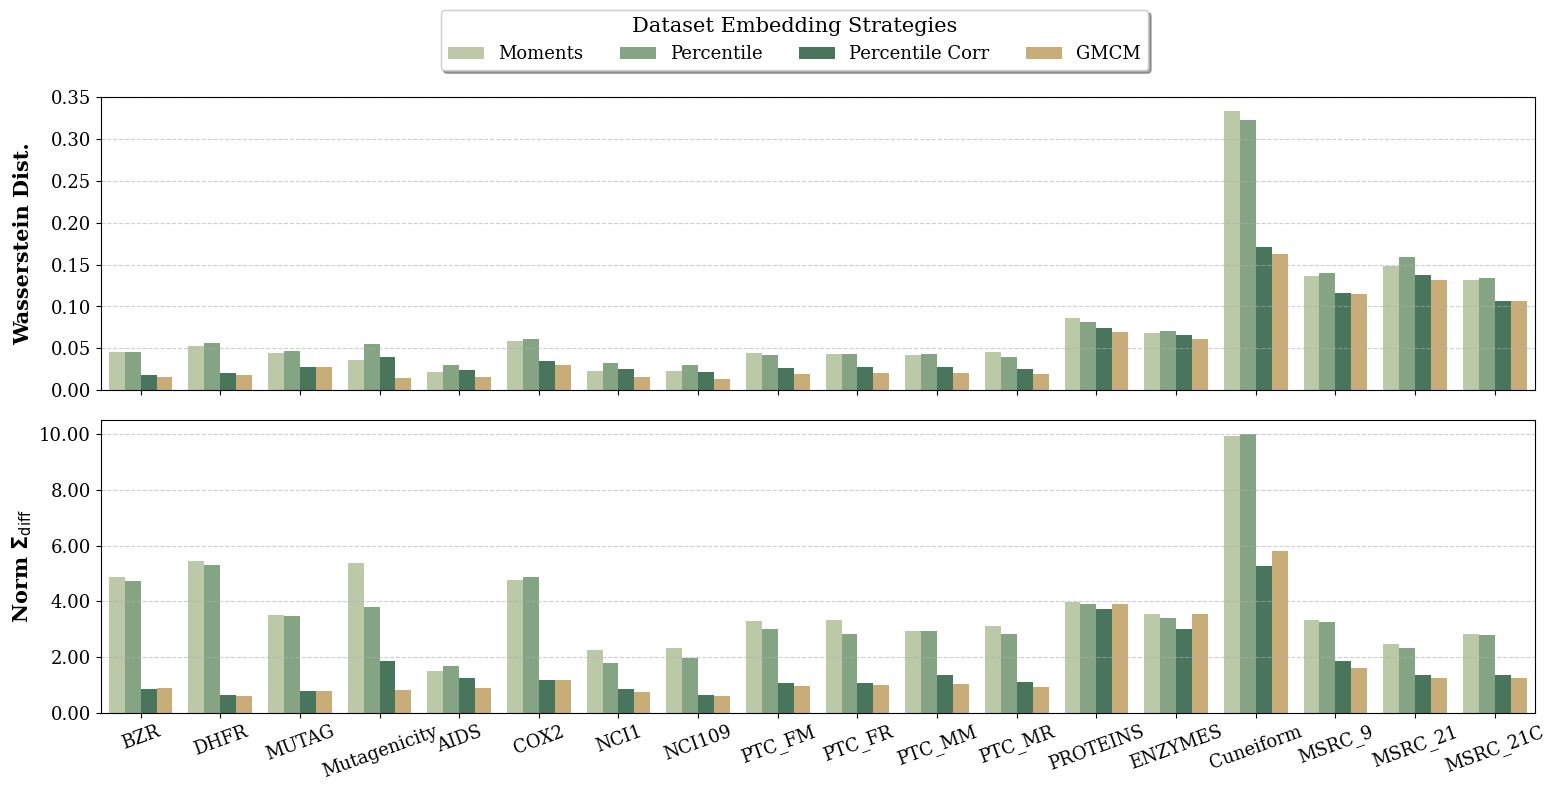

In [28]:
def _compute_rf_score(dataset: str, vary_col: str, vary_vals: list,
                      error_col: str = "synth",
                      rf_metric: str = "accuracy") -> pd.DataFrame:
    """Train a Random Forest to distinguish original from generated graphs.

    For each (vary_val, variant) pair, builds a binary classification dataset
    (original=0, generated=1) using ALL_STAT_COLS as features, trains a
    RandomForestClassifier with a stratified 70/30 split, and returns the
    chosen evaluation metric.

    A score close to 0.5 means the generated data is statistically
    indistinguishable from the original; close to 1.0 means easily separable.

    Args:
        dataset: Dataset name.
        vary_col: Column name of the free axis ('method' or 'sampler').
        vary_vals: Ordered list of values along the free axis.
        error_col: 'target' or 'synth' — which generated data to use.
        rf_metric: One of 'accuracy', 'f1', or 'auc_roc'.
    Returns:
        DataFrame with columns [vary_col, 'variant', 'rf_score'].
    """
    if rf_metric not in ("accuracy", "f1", "auc_roc"):
        raise ValueError(f"rf_metric must be 'accuracy', 'f1', or 'auc_roc', got '{rf_metric}'.")

    orig = df_original[df_original["dataset"] == dataset][ALL_STAT_COLS].dropna().fillna(0)
    synth_ds = df_synthetic[df_synthetic["dataset"] == dataset]

    prefix = error_col  # 'synth' or 'target'
    rows = []
    for val in vary_vals:
        sub = synth_ds[synth_ds[vary_col] == val]
        for variant, grp in sub.groupby("variant", observed=True):
            gen_feats = (
                grp[[f"{prefix}_{c}" for c in ALL_STAT_COLS]]
                .rename(columns={f"{prefix}_{c}": c for c in ALL_STAT_COLS})
                .fillna(0)
            )

            X_orig = orig.values
            X_gen  = gen_feats.values
            y_orig = np.zeros(len(X_orig))
            y_gen  = np.ones(len(X_gen))

            X = np.vstack([X_orig, X_gen])
            y = np.concatenate([y_orig, y_gen])

            # Need enough samples per class for a stratified split
            if min(len(X_orig), len(X_gen)) < 5:
                continue

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y,
            )
            rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)

            if rf_metric == "accuracy":
                score = rf.score(X_test, y_test)
            elif rf_metric == "f1":
                score = f1_score(y_test, rf.predict(X_test))
            else:  # auc_roc
                score = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

            rows.append({vary_col: val, "variant": variant, "rf_score": score})

    return pd.DataFrame(rows)

# Human-readable labels for each RF metric
_RF_METRIC_LABELS = {
    "accuracy": "RF Accuracy",
    "f1":       "RF F1-Score",
    "auc_roc":  "RF AUC-ROC",
}

def plot_errors_barplot(error_col: str = "synth",
                        rf_metric: str | None = "accuracy") -> None:
    """Bar chart: Wasserstein (top), Frobenius norm (mid), optionally RF score (bottom).

    Vertically stacked subplots share the x-axis (Dataset).
    Bars are grouped by the free axis (method or sampler).

    If rf_metric is provided, a third row shows the mean test score of a Random Forest 
    trained to distinguish original from generated stat vectors. A score near 0.5 
    indicates indistinguishable distributions; near 1.0 means trivially separable.

    Args:
        error_col: 'target' or 'synth' — which comparison to plot.
        rf_metric: 'accuracy', 'f1', 'auc_roc', or None — evaluation metric for the
                   Random Forest classifier. If None, the RF plot is omitted.
    """
    vary_col, vary_vals, palette, axis_label = _resolve_vary_col()
    rf_label = _RF_METRIC_LABELS.get(rf_metric) if rf_metric else None

    rows = []
    for dataset in DATASETS:
        df_marg  = _compute_marginal_errors(dataset, vary_col, vary_vals)
        df_joint = _compute_joint_errors(dataset, vary_col, vary_vals)
        merged   = df_marg.merge(df_joint, on=[vary_col, "variant"])
        
        if rf_metric is not None:
            df_rf    = _compute_rf_score(dataset, vary_col, vary_vals, error_col, rf_metric)
            if not df_rf.empty:
                merged = merged.merge(df_rf, on=[vary_col, "variant"], how="left")

        for val in vary_vals:
            sub = merged[merged[vary_col] == val]
            if sub.empty:
                continue
            row = {
                "Dataset":        dataset,
                vary_col:         val,
                "Marginal Error": sub[f"marginal_error_{error_col}"].mean(),
                "Joint Error":    sub[f"joint_error_{error_col}"].mean(),
            }
            if rf_metric is not None and "rf_score" in sub.columns:
                row[rf_label] = sub["rf_score"].mean()
            rows.append(row)

    df_plot = pd.DataFrame(rows)
    if df_plot.empty:
        print("No data to plot.")
        return

    nrows = 3 if rf_metric is not None else 2
    fig_height = 11 if rf_metric is not None else 8
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(18.5, fig_height), sharex=True)

    metrics = [
        ("Marginal Error", axes[0], "Wasserstein Dist."),
        ("Joint Error",    axes[1], r"Norm $\mathbf{\Sigma_\text{diff}}$"),
    ]
    if rf_metric is not None:
        metrics.append((rf_label, axes[2], rf_label))

    handles, labels = None, None
    for metric, ax, ylabel in metrics:
        vary_col_palette = {str(v): palette.get(str(v), "#AAAAAA") for v in vary_vals}
        sns.barplot(
            data=df_plot,
            x="Dataset",
            y=metric,
            hue=vary_col,
            hue_order=vary_vals,
            palette=vary_col_palette,
            alpha=0.9,
            ax=ax,
        )
        ax.set_ylabel(ylabel, fontsize=15, fontweight="bold")
        ax.set_xlabel("")
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis='x', labelsize=13, rotation=20)
        ax.tick_params(axis='y', labelsize=13)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

        # Collect handles once (before removing legends)
        if handles is None and ax.get_legend() is not None:
            handles, labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    if rf_metric is not None:
        # Reference line at 0.5 (chance level) on the RF subplot
        axes[2].axhline(0.5, color="grey", linestyle=":", linewidth=1.2, label="chance")
        
    # Align y-labels vertically across all subplots
    fig.align_ylabels(axes)

    # Shared legend at the top, centred
    clean_labels = [METHOD_LABELS.get(str(l), str(l).replace("_", " ")) for l in (labels or [])]
    fig.legend(
        handles or [],
        clean_labels,
        title=axis_label,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(vary_vals),
        fontsize=13,
        title_fontsize=15,
        frameon=True,
        shadow=True,
    )

    fig.subplots_adjust(hspace=0.1)
    save_figure_pdf(fig, ax, PROJECT_ROOT / "dataset_distribution_modelling.pdf")
    plt.show()

plot_errors_barplot(error_col="synth", rf_metric=None)